Import and reading Data


In [17]:
#Importing data_csv database
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/final_clean_data_train (1)-1 (1).csv')
print('Data imported succesfully')

Data imported succesfully


In [63]:
# Create a copy of the template DataFrame to fill
filled_guidelines_df = guidelines_df_template.copy()

# --- Classification Section ---
# Mapping template column names to actual metric names for classification results
template_clf_cols = {
    'Unnamed: 1': 'Test_Accuracy',
    'Unnamed: 2': 'Test_Precision',
    'Unnamed: 3': 'Test_Recall',
    'Unnamed: 4': 'Test_F1',
    'Unnamed: 5': 'Test_ROC_AUC'
}

# Find the end of the classification models section or the start of the regression section
classification_models_end_idx = len(filled_guidelines_df) - 1
if 'Regression' in filled_guidelines_df['Model'].values:
    classification_models_end_idx = filled_guidelines_df[filled_guidelines_df['Model'] == 'Regression'].index[0] - 1

for i in range(classification_models_end_idx + 1):
    model_name_template = str(filled_guidelines_df.loc[i, 'Model'])
    if pd.isna(filled_guidelines_df.loc[i, 'Model']) or 'Which model' in model_name_template:
        continue

    # Try to match with classification_comparison_df
    matched_row = None
    if 'Logistic Regression' in model_name_template:
        matched_row = classification_comparison_df[classification_comparison_df['Model'] == 'Logistic Regression']
    elif 'Decision Tree' in model_name_template:
        matched_row = classification_comparison_df[classification_comparison_df['Model'] == 'Decision Tree']
    elif 'Random Forest' in model_name_template:
        matched_row = classification_comparison_df[classification_comparison_df['Model'] == 'Random Forest']
    elif 'Gradient Boosting' in model_name_template:
        matched_row = classification_comparison_df[classification_comparison_df['Model'] == 'Gradient Boosting']
    elif 'K-Nearest Neighbors' in model_name_template or 'KNN' in model_name_template:
        matched_row = classification_comparison_df[classification_comparison_df['Model'] == 'KNN']
    elif 'Support Vector Classifier (SVC)' in model_name_template or 'SVC' in model_name_template:
        matched_row = classification_comparison_df[classification_comparison_df['Model'] == 'SVC']
    elif 'Voting' in model_name_template or 'Ensemble' in model_name_template:
        matched_row = classification_comparison_df[classification_comparison_df['Model'] == 'Voting Ensemble']

    if matched_row is not None and not matched_row.empty:
        for template_col, result_col in template_clf_cols.items():
            filled_guidelines_df.loc[i, template_col] = f"{matched_row.iloc[0][result_col]:.4f}"

# --- Regression Section ---
# Mapping template column names to actual metric names for regression results
template_reg_cols = {
    'Unnamed: 1': 'MAE',
    'Unnamed: 2': 'MSE',
    'Unnamed: 3': 'R2'
}

# Find the regression section start index
regression_start_idx = filled_guidelines_df[filled_guidelines_df['Model'] == 'Regression'].index
if not regression_start_idx.empty:
    regression_start_idx = regression_start_idx[0]
    for i in range(regression_start_idx + 1, len(filled_guidelines_df)):
        model_name_template = str(filled_guidelines_df.loc[i, 'Model'])
        if pd.isna(filled_guidelines_df.loc[i, 'Model']) or 'Which model' in model_name_template:
            continue

        # Try to match with results (regression comparison df)
        matched_row = None
        if 'Linear Regression' in model_name_template:
            matched_row = results[results['Model'] == 'Linear Regression']
        elif 'Decision Tree' in model_name_template:
            matched_row = results[results['Model'] == 'Decision Tree']
        elif 'Random Forest' in model_name_template:
            matched_row = results[results['Model'] == 'Random Forest']
        elif 'Gradient Boosting' in model_name_template:
            matched_row = results[results['Model'] == 'Gradient Boosting']
        elif 'K-Nearest Neighbors' in model_name_template or 'KNN' in model_name_template:
            matched_row = results[results['Model'] == 'KNN']
        elif 'Voting' in model_name_template or 'Ensemble' in model_name_template:
            matched_row = results[results['Model'] == 'Voting Ensemble']

        if matched_row is not None and not matched_row.empty:
            for template_col, result_col in template_reg_cols.items():
                filled_guidelines_df.loc[i, template_col] = f"{matched_row.iloc[0][result_col]:.4f}"

# --- Best/Worst Model Analysis Section ---
# Classification Best/Worst Model
classification_best_worst_idx = filled_guidelines_df[
    (filled_guidelines_df['Model'].str.contains('Which model gave you the best result', na=False)) &
    (filled_guidelines_df.index < regression_start_idx if 'Regression' in filled_guidelines_df['Model'].values else True)
].index

if not classification_best_worst_idx.empty:
    idx = classification_best_worst_idx[0]
    # Based on the previous analysis (text cell fb578d45), all classification models performed poorly.
    # Logistic Regression had the highest ROC-AUC but 0 precision/recall/f1, indicating it's not truly 'best' for the positive class.
    # SVC had the lowest ROC-AUC and 0 for other metrics.
    best_clf_model_name = "Logistic Regression (with caveats)"
    worst_clf_model_name = "SVC"
    filled_guidelines_df.loc[idx, 'Unnamed: 1'] = f"Best: {best_clf_model_name} (Test ROC-AUC: {classification_comparison_df[classification_comparison_df['Model'] == 'Logistic Regression']['Test_ROC_AUC'].iloc[0]:.4f}, but precision/recall are 0)"
    filled_guidelines_df.loc[idx, 'Unnamed: 2'] = f"Worst: {worst_clf_model_name} (Test ROC-AUC: {classification_comparison_df[classification_comparison_df['Model'] == 'SVC']['Test_ROC_AUC'].iloc[0]:.4f})"

# Regression Best/Worst Model
regression_best_worst_idx = filled_guidelines_df[
    (filled_guidelines_df['Model'].str.contains('Which model gave you the best result', na=False)) &
    (filled_guidelines_df.index > regression_start_idx)
].index

if not regression_best_worst_idx.empty:
    idx = regression_best_worst_idx[0]
    best_reg_model_row = results.sort_values(by="R2", ascending=False).iloc[0]
    worst_reg_model_row = results.sort_values(by="R2", ascending=True).iloc[0]
    best_reg_model_name = best_reg_model_row['Model']
    best_reg_r2 = best_reg_model_row['R2']
    worst_reg_model_name = worst_reg_model_row['Model']
    worst_reg_r2 = worst_reg_model_row['R2']
    filled_guidelines_df.loc[idx, 'Unnamed: 1'] = f"Best: {best_reg_model_name} (Test R2: {best_reg_r2:.4f})"
    filled_guidelines_df.loc[idx, 'Unnamed: 2'] = f"Worst: {worst_reg_model_name} (Test R2: {worst_reg_r2:.4f})"

display(filled_guidelines_df)

,Model,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Logistic Regression,0.6429,0.0000,0.0000,0.0000,0.5109
1,Decision Tree Classifier,0.5190,0.3481,0.3973,0.3711,0.4920
2,Random Forest Classifier,0.6219,0.3514,0.0693,0.1158,0.4834
3,"Gradient Boosting Classifier (e.g., XGBoost or...",0.6390,0.4000,0.0213,0.0405,0.4985
4,K-Nearest Neighbors Classifier,0.5524,0.3285,0.2427,0.2791,0.4524
5,Support Vector Classifier (SVC),0.6419,0.0000,0.0000,0.0000,0.4514
6,Voting Vs Avearge (best 3 out of 6 ),0.6400,0.3636,0.0107,0.0207,0.4887
7,Ensemble,0.6400,0.3636,0.0107,0.0207,0.4887
8,NaN,NaN,NaN,NaN,NaN,NaN
9,Which model gave you the best result and whic...,Best: Logistic Regression (with caveats) (Test...,Worst: SVC (Test ROC-AUC: 0.4514),NaN,NaN,NaN


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
from google.colab import files

print("Please select the file 'final_clean_data_train (1)-1.csv' to upload:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Please select the file 'final_clean_data_train (1)-1.csv' to upload:


Saving final_clean_data_train (1)-1.csv to final_clean_data_train (1)-1 (2).csv
User uploaded file "final_clean_data_train (1)-1 (2).csv" with length 882358 bytes


After the file is uploaded, please re-run the data loading cell (`Dxf10EqxTYSP`) and all subsequent cells to continue with the notebook.

In [ ]:
import os
print(os.listdir('/content/'))

Visualization

In [ ]:
df.columns

In [22]:
print('-----Dataset before cleanup-----')
display(df.head())
print('-----Missing values-----')
print(df.isnull().sum())

-----Dataset before cleanup-----


,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Parental_Education,GPA_Trend,Time_Pressure,Income_Study_Ratio,Gender_Male,Internet_Access_Yes,Part_Time_Job_Yes,Scholarship_Yes
0,18.6,-0.475324,4.610000,77.5,3,10.2,3.600000,4.00,3.55,3.48,3,1,0.07,190.2,5072.014260,False,True,False,False
1,21.1,2.797731,4.730000,78.2,0,29.6,5.200000,2.38,2.13,2.13,4,3,0.00,29.6,16340.837696,False,True,True,True
2,22.1,-0.408486,4.027432,94.4,1,23.8,5.515948,4.00,4.00,4.00,2,1,0.00,83.8,5924.496004,False,True,True,True
3,18.9,-0.505303,2.870000,74.2,1,36.1,6.900000,2.76,3.06,3.06,1,5,0.00,96.1,7198.191214,False,False,False,True
4,22.4,-0.288217,2.430000,60.8,1,39.5,2.300000,1.05,0.68,0.68,4,3,0.00,99.5,9381.924198,True,True,False,False


-----Missing values-----
Age                      0
Family_Income            0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Parental_Education       0
GPA_Trend                0
Time_Pressure            0
Income_Study_Ratio       0
Gender_Male              0
Internet_Access_Yes      0
Part_Time_Job_Yes        0
Scholarship_Yes          0
dtype: int64


In [23]:
print('Unnecesary features: Student_ID , Department')
df.head(10)

Unnecesary features: Student_ID , Department


,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Parental_Education,GPA_Trend,Time_Pressure,Income_Study_Ratio,Gender_Male,Internet_Access_Yes,Part_Time_Job_Yes,Scholarship_Yes
0,18.6,-0.475324,4.610000,77.5,3,10.2,3.600000,4.00,3.55,3.48,3,1,0.07,190.2,5072.014260,False,True,False,False
1,21.1,2.797731,4.730000,78.2,0,29.6,5.200000,2.38,2.13,2.13,4,3,0.00,29.6,16340.837696,False,True,True,True
2,22.1,-0.408486,4.027432,94.4,1,23.8,5.515948,4.00,4.00,4.00,2,1,0.00,83.8,5924.496004,False,True,True,True
3,18.9,-0.505303,2.870000,74.2,1,36.1,6.900000,2.76,3.06,3.06,1,5,0.00,96.1,7198.191214,False,False,False,True
4,22.4,-0.288217,2.430000,60.8,1,39.5,2.300000,1.05,0.68,0.68,4,3,0.00,99.5,9381.924198,True,True,False,False
5,17.3,0.324372,4.110000,87.2,2,5.0,6.800000,2.29,2.52,2.49,4,4,0.03,125.0,8684.735812,False,True,False,False
6,20.0,1.795211,1.520000,86.4,5,36.2,5.800000,1.51,1.73,1.78,2,1,-0.05,336.2,29233.730159,True,False,False,False
7,20.0,-0.408486,4.027432,80.4,2,45.4,5.515948,1.74,1.54,1.59,2,2,-0.05,165.4,5924.496004,True,True,True,False
8,22.3,5.515442,4.640000,79.2,2,26.1,5.300000,0.00,0.00,0.00,1,2,0.00,146.1,26197.340426,True,True,False,False
9,24.3,-0.260548,4.800000,94.8,2,22.6,3.900000,4.00,3.95,3.95,1,1,0.00,142.6,5643.275862,True,True,False,True


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    7000 non-null   float64
 1   Family_Income          7000 non-null   float64
 2   Study_Hours_per_Day    7000 non-null   float64
 3   Attendance_Rate        7000 non-null   float64
 4   Assignment_Delay_Days  7000 non-null   int64  
 5   Travel_Time_Minutes    7000 non-null   float64
 6   Stress_Index           7000 non-null   float64
 7   GPA                    7000 non-null   float64
 8   Semester_GPA           7000 non-null   float64
 9   CGPA                   7000 non-null   float64
 10  Semester               7000 non-null   int64  
 11  Parental_Education     7000 non-null   int64  
 12  GPA_Trend              7000 non-null   float64
 13  Time_Pressure          7000 non-null   float64
 14  Income_Study_Ratio     7000 non-null   float64
 15  Gend

In [25]:
df.describe()

,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Parental_Education,GPA_Trend,Time_Pressure,Income_Study_Ratio
count,7000.000000,7.000000e+03,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,21.010243,1.400784e-16,4.027432,81.730643,1.808143,30.186514,5.515948,2.305937,2.294026,2.292624,2.527000,2.054571,0.001401,138.675086,8142.610319
std,2.148077,1.000071e+00,1.268364,8.154187,1.348499,11.965915,1.730897,1.061569,1.075866,1.073967,1.118938,1.122014,0.042422,81.879981,5099.171262
min,17.000000,-6.487709e-01,0.500000,41.400000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,-0.190000,5.000000,2545.824847
25%,19.500000,-6.487709e-01,3.220000,76.400000,1.000000,21.800000,4.400000,1.550000,1.510000,1.510000,2.000000,1.000000,-0.020000,83.075000,5010.033419
50%,21.000000,-4.084855e-01,4.027432,81.800000,2.000000,30.200000,5.515948,2.340000,2.320000,2.330000,3.000000,2.000000,0.000000,137.550000,6345.177665
75%,22.500000,2.682557e-01,4.840000,87.125000,3.000000,38.500000,6.600000,3.130000,3.150000,3.150000,4.000000,3.000000,0.020000,197.800000,9474.022763
max,29.600000,1.113084e+01,8.830000,100.000000,8.000000,74.900000,10.000000,4.000000,4.000000,4.000000,4.000000,5.000000,0.170000,525.100000,61699.236641


Text(0.5, 0, '$')

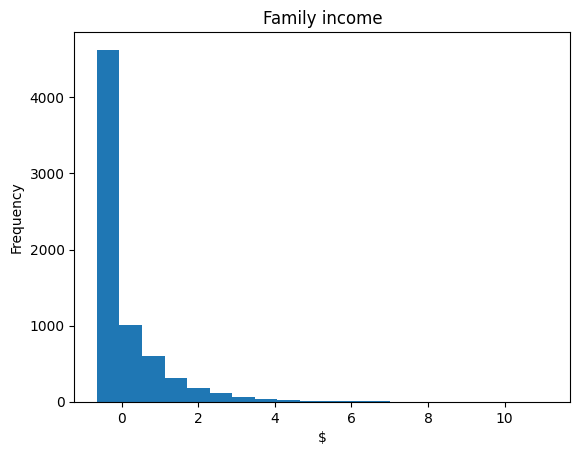

In [26]:
ax = df['Family_Income'].plot(kind='hist',
                     bins=20,
                     title= 'Family income')
ax.set_xlabel('$')

In [27]:
df['Parental_Education'] = df['Parental_Education'].fillna('Unknown')

In [28]:
df.isna().sum()

,0
Age,0
Family_Income,0
Study_Hours_per_Day,0
Attendance_Rate,0
Assignment_Delay_Days,0
Travel_Time_Minutes,0
Stress_Index,0
GPA,0
Semester_GPA,0
CGPA,0


In [29]:
from sklearn.model_selection import train_test_split

# Drop CGPA, GPA, and Semester_GPA to prevent data leakage
X = df.drop(['CGPA', 'GPA', 'Semester_GPA'], axis=1)
y = df['CGPA']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [30]:
print(f"Training rows: {X_train.shape[0]}")
print(f"Validation rows: {X_val.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

Training rows: 4900
Validation rows: 1050
Testing rows: 1050


In [31]:
print('Features with missing values: Family_Income,Study_Hours_per_Day, and Stress_Index')

Features with missing values: Family_Income,Study_Hours_per_Day, and Stress_Index


In [32]:
FamilyIncome_median = X_train['Family_Income'].median()
Studyhours_mean = X_train['Study_Hours_per_Day'].mean()
StressIndex_mean = X_train['Stress_Index'].mean()

In [33]:
X_train['Family_Income'] = X_train['Family_Income'].fillna(FamilyIncome_median)
X_train['Study_Hours_per_Day'] = X_train['Study_Hours_per_Day'].fillna(Studyhours_mean)
X_train['Stress_Index'] = X_train['Stress_Index'].fillna(StressIndex_mean)

Feature Engineering

In [34]:
for dataset in [X_train, X_val, X_test]:

    # 'CGPA' is now the target variable, so we cannot use it to create 'GPA_Trend' in the features.
    # The original 'GPA_Trend' column exists in X and is kept as a feature.
    # dataset['GPA_Trend'] = dataset['Semester_GPA'] - dataset['CGPA'] # Removed

    dataset['Time_Pressure'] = dataset['Travel_Time_Minutes'] + (dataset['Assignment_Delay_Days'] * 60)

    dataset['Income_Study_Ratio'] = dataset['Family_Income'] / (dataset['Study_Hours_per_Day'] + 1)

print("Feature Engineering Complete!")

Feature Engineering Complete!


In [35]:
X_val['Family_Income'] = X_val['Family_Income'].fillna(FamilyIncome_median)
X_val['Study_Hours_per_Day'] = X_val['Study_Hours_per_Day'].fillna(Studyhours_mean)
X_val['Stress_Index'] = X_val['Stress_Index'].fillna(StressIndex_mean)

X_test['Family_Income'] = X_test['Family_Income'].fillna(FamilyIncome_median)
X_test['Study_Hours_per_Day'] = X_test['Study_Hours_per_Day'].fillna(Studyhours_mean)
X_test['Stress_Index'] = X_test['Stress_Index'].fillna(StressIndex_mean)

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Scale Family_Income
X_train['Family_Income'] = scaler.fit_transform(X_train[['Family_Income']])
X_val['Family_Income'] = scaler.transform(X_val[['Family_Income']])
X_test['Family_Income'] = scaler.transform(X_test[['Family_Income']])

# Define numerical columns to scale
num_cols_to_scale = [
    'Age', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
    'Travel_Time_Minutes', 'Stress_Index', 'Semester',
    'GPA_Trend', 'Time_Pressure', 'Income_Study_Ratio'
]

# Filter to only include columns that exist in X_train
num_cols_to_scale = [col for col in num_cols_to_scale if col in X_train.columns]

X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_val[num_cols_to_scale] = scaler.transform(X_val[num_cols_to_scale])
X_test[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

print("Features have been scaled!")

Features have been scaled!


In [37]:
print("X_train info:")
display(X_train.info())
print("\nX_val info:")
display(X_val.info())
print("\nX_test info:")
display(X_test.info())

X_train info:
<class 'pandas.core.frame.DataFrame'>
Index: 4900 entries, 1612 to 860
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    4900 non-null   float64
 1   Family_Income          4900 non-null   float64
 2   Study_Hours_per_Day    4900 non-null   float64
 3   Attendance_Rate        4900 non-null   float64
 4   Assignment_Delay_Days  4900 non-null   float64
 5   Travel_Time_Minutes    4900 non-null   float64
 6   Stress_Index           4900 non-null   float64
 7   Semester               4900 non-null   float64
 8   Parental_Education     4900 non-null   int64  
 9   GPA_Trend              4900 non-null   float64
 10  Time_Pressure          4900 non-null   float64
 11  Income_Study_Ratio     4900 non-null   float64
 12  Gender_Male            4900 non-null   bool   
 13  Internet_Access_Yes    4900 non-null   bool   
 14  Part_Time_Job_Yes      4900 non-null   bool  

None


X_val info:
<class 'pandas.core.frame.DataFrame'>
Index: 1050 entries, 1535 to 6637
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1050 non-null   float64
 1   Family_Income          1050 non-null   float64
 2   Study_Hours_per_Day    1050 non-null   float64
 3   Attendance_Rate        1050 non-null   float64
 4   Assignment_Delay_Days  1050 non-null   float64
 5   Travel_Time_Minutes    1050 non-null   float64
 6   Stress_Index           1050 non-null   float64
 7   Semester               1050 non-null   float64
 8   Parental_Education     1050 non-null   int64  
 9   GPA_Trend              1050 non-null   float64
 10  Time_Pressure          1050 non-null   float64
 11  Income_Study_Ratio     1050 non-null   float64
 12  Gender_Male            1050 non-null   bool   
 13  Internet_Access_Yes    1050 non-null   bool   
 14  Part_Time_Job_Yes      1050 non-null   bool  

None


X_test info:
<class 'pandas.core.frame.DataFrame'>
Index: 1050 entries, 4006 to 1966
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1050 non-null   float64
 1   Family_Income          1050 non-null   float64
 2   Study_Hours_per_Day    1050 non-null   float64
 3   Attendance_Rate        1050 non-null   float64
 4   Assignment_Delay_Days  1050 non-null   float64
 5   Travel_Time_Minutes    1050 non-null   float64
 6   Stress_Index           1050 non-null   float64
 7   Semester               1050 non-null   float64
 8   Parental_Education     1050 non-null   int64  
 9   GPA_Trend              1050 non-null   float64
 10  Time_Pressure          1050 non-null   float64
 11  Income_Study_Ratio     1050 non-null   float64
 12  Gender_Male            1050 non-null   bool   
 13  Internet_Access_Yes    1050 non-null   bool   
 14  Part_Time_Job_Yes      1050 non-null   bool 

None

one - hot encoding

In [38]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4900 entries, 1612 to 860
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    4900 non-null   float64
 1   Family_Income          4900 non-null   float64
 2   Study_Hours_per_Day    4900 non-null   float64
 3   Attendance_Rate        4900 non-null   float64
 4   Assignment_Delay_Days  4900 non-null   float64
 5   Travel_Time_Minutes    4900 non-null   float64
 6   Stress_Index           4900 non-null   float64
 7   Semester               4900 non-null   float64
 8   Parental_Education     4900 non-null   int64  
 9   GPA_Trend              4900 non-null   float64
 10  Time_Pressure          4900 non-null   float64
 11  Income_Study_Ratio     4900 non-null   float64
 12  Gender_Male            4900 non-null   bool   
 13  Internet_Access_Yes    4900 non-null   bool   
 14  Part_Time_Job_Yes      4900 non-null   bool   
 15  Scholar

In [39]:
education_mapping = {'Bachelor': 1, 'High School': 2, 'Master': 3, 'PhD': 4, 'Unknown': 5}

# No mapping needed for Parental_Education as it's already numerical and clean.

# Identify object columns for one-hot encoding
cols_to_onehot_encode = [col for col in X_train.columns if X_train[col].dtype == 'object']

# Apply one-hot encoding
X_train = pd.get_dummies(X_train, columns=cols_to_onehot_encode, drop_first=True)
X_val = pd.get_dummies(X_val, columns=cols_to_onehot_encode, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_to_onehot_encode, drop_first=True)

# Reindex X_val and X_test to match X_train columns
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [40]:
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of y_train: (4900,)
Shape of y_val: (1050,)
Shape of y_test: (1050,)


In [41]:
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "Bayesian Ridge": BayesianRidge()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)

    print(f"\n--- {name} ---")
    print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train):.4f}")
    print(f"Train MSE: {mean_squared_error(y_train, y_pred_train):.4f}")
    print(f"Train R2: {r2_score(y_train, y_pred_train):.4f}")
    print(f"Validation MAE: {mean_absolute_error(y_val, y_pred_val):.4f}")
    print(f"Validation MSE: {mean_squared_error(y_val, y_pred_val):.4f}")
    print(f"Validation R2: {r2_score(y_val, y_pred_val):.4f}")
    print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test):.4f}")
    print(f"Test MSE: {mean_squared_error(y_test, y_pred_test):.4f}")
    print(f"Test R2: {r2_score(y_test, y_pred_test):.4f}")


--- Linear Regression ---
Train MAE: 0.7911
Train MSE: 0.9245
Train R2: 0.2093
Validation MAE: 0.7568
Validation MSE: 0.8720
Validation R2: 0.2102
Test MAE: 0.7624
Test MSE: 0.8739
Test R2: 0.2237

--- Decision Tree ---
Train MAE: 0.0000
Train MSE: 0.0000
Train R2: 1.0000
Validation MAE: 1.0760
Validation MSE: 1.8357
Validation R2: -0.6626
Test MAE: 1.0350
Test MSE: 1.7004
Test R2: -0.5106

--- Random Forest ---
Train MAE: 0.3012
Train MSE: 0.1365
Train R2: 0.8833
Validation MAE: 0.7784
Validation MSE: 0.9239
Validation R2: 0.1633
Test MAE: 0.7886
Test MSE: 0.9290
Test R2: 0.1747

--- Gradient Boosting ---
Train MAE: 0.7459
Train MSE: 0.8225
Train R2: 0.2966
Validation MAE: 0.7691
Validation MSE: 0.8934
Validation R2: 0.1909
Test MAE: 0.7698
Test MSE: 0.8860
Test R2: 0.2128

--- KNN ---
Train MAE: 0.7131
Train MSE: 0.7665
Train R2: 0.3444
Validation MAE: 0.8550
Validation MSE: 1.1089
Validation R2: -0.0043
Test MAE: 0.8379
Test MSE: 1.0569
Test R2: 0.0610

--- Bayesian Ridge ---
Train

In [42]:
from sklearn.ensemble import VotingRegressor

ensemble = VotingRegressor([
    ('rf', RandomForestRegressor(random_state=42)),
    ('gb', GradientBoostingRegressor(random_state=42)),
    ('lr', LinearRegression())
])

ensemble.fit(X_train, y_train)

y_pred_train = ensemble.predict(X_train)
y_pred_val = ensemble.predict(X_val)
y_pred_test = ensemble.predict(X_test)

print("\n--- Ensemble Model (VotingRegressor) ---")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train):.4f}")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_train):.4f}")
print(f"Train R2: {r2_score(y_train, y_pred_train):.4f}")
print(f"Validation MAE: {mean_absolute_error(y_val, y_pred_val):.4f}")
print(f"Validation MSE: {mean_squared_error(y_val, y_pred_val):.4f}")
print(f"Validation R2: {r2_score(y_val, y_pred_val):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"Test MSE: {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"Test R2: {r2_score(y_test, y_pred_test):.4f}")


--- Ensemble Model (VotingRegressor) ---
Train MAE: 0.6092
Train MSE: 0.5470
Train R2: 0.5322
Validation MAE: 0.7629
Validation MSE: 0.8814
Validation R2: 0.2017
Test MAE: 0.7670
Test MSE: 0.8808
Test R2: 0.2175


In [43]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "KNN",
        "Voting Ensemble"
    ],
    "MAE": [
        0.7624,
        1.0350,
        0.7886,
        0.7698,
        0.8379,
        0.7670
    ],
    "MSE": [
        0.8739,
        1.7004,
        0.9290,
        0.8860,
        1.0569,
        0.8808
    ],
    "R2": [
        0.2237,
        -0.5106,
        0.1747,
        0.2128,
        0.0610,
        0.2175
    ]
})

print("\n--- Model Comparison Table (Test Set) ---")
print(results.sort_values(by="R2", ascending=False))


--- Model Comparison Table (Test Set) ---
               Model     MAE     MSE      R2
0  Linear Regression  0.7624  0.8739  0.2237
5    Voting Ensemble  0.7670  0.8808  0.2175
3  Gradient Boosting  0.7698  0.8860  0.2128
2      Random Forest  0.7886  0.9290  0.1747
4                KNN  0.8379  1.0569  0.0610
1      Decision Tree  1.0350  1.7004 -0.5106


## Classification Problem: Predicting Scholarship Status

In [44]:
from sklearn.model_selection import train_test_split

# Define features (X_clf) and target (y_clf) for classification
# Scholarship_Yes will be our target variable
X_clf = df.drop('Scholarship_Yes', axis=1)
y_clf = df['Scholarship_Yes']

# Convert Parental_Education to object type if it's categorical (1-5 values)
# This is based on the assumption that it represents categories like 'Bachelor', 'High School', etc.
# as implied by the previous education_mapping. If it's truly ordinal, this step can be skipped.
if X_clf['Parental_Education'].dtype == 'int64' and X_clf['Parental_Education'].nunique() <= 5:
    X_clf['Parental_Education'] = X_clf['Parental_Education'].astype('object')

# Split data into training, validation, and test sets (70/15/15 split)
X_train_clf, X_temp_clf, y_train_clf, y_temp_clf = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf)
X_val_clf, X_test_clf, y_val_clf, y_test_clf = train_test_split(X_temp_clf, y_temp_clf, test_size=0.5, random_state=42, stratify=y_temp_clf)

print("Classification data split successfully!")

Classification data split successfully!


In [45]:
print(f"Training rows for Classification: {X_train_clf.shape[0]}")
print(f"Validation rows for Classification: {X_val_clf.shape[0]}")
print(f"Testing rows for Classification: {X_test_clf.shape[0]}")

print("\nTarget variable distribution in training set:")
print(y_train_clf.value_counts(normalize=True))
print("\nTarget variable distribution in validation set:")
print(y_val_clf.value_counts(normalize=True))
print("\nTarget variable distribution in test set:")
print(y_test_clf.value_counts(normalize=True))

Training rows for Classification: 4900
Validation rows for Classification: 1050
Testing rows for Classification: 1050

Target variable distribution in training set:
Scholarship_Yes
False    0.642245
True     0.357755
Name: proportion, dtype: float64

Target variable distribution in validation set:
Scholarship_Yes
False    0.641905
True     0.358095
Name: proportion, dtype: float64

Target variable distribution in test set:
Scholarship_Yes
False    0.642857
True     0.357143
Name: proportion, dtype: float64


### Feature Engineering for Classification

In [46]:
for dataset in [X_train_clf, X_val_clf, X_test_clf]:
    # Re-creating new features based on the context of X_clf
    dataset['Time_Pressure'] = dataset['Travel_Time_Minutes'] + (dataset['Assignment_Delay_Days'] * 60)
    dataset['Income_Study_Ratio'] = dataset['Family_Income'] / (dataset['Study_Hours_per_Day'] + 1)

print("Feature Engineering Complete for Classification Data!")

Feature Engineering Complete for Classification Data!


### Scaling Numerical Features for Classification

In [47]:
from sklearn.preprocessing import StandardScaler

scaler_clf = StandardScaler()

# Identify numerical columns for scaling
# Exclude boolean and object (categorical) columns
num_cols_to_scale_clf = X_train_clf.select_dtypes(include=np.number).columns.tolist()

# Apply scaling
X_train_clf[num_cols_to_scale_clf] = scaler_clf.fit_transform(X_train_clf[num_cols_to_scale_clf])
X_val_clf[num_cols_to_scale_clf] = scaler_clf.transform(X_val_clf[num_cols_to_scale_clf])
X_test_clf[num_cols_to_scale_clf] = scaler_clf.transform(X_test_clf[num_cols_to_scale_clf])

print("Numerical features scaled for Classification Data!")

Numerical features scaled for Classification Data!


### One-Hot Encoding Categorical Features for Classification

In [48]:
# Identify object columns for one-hot encoding in classification data
cols_to_onehot_encode_clf = X_train_clf.select_dtypes(include='object').columns.tolist()

# Apply one-hot encoding
X_train_clf = pd.get_dummies(X_train_clf, columns=cols_to_onehot_encode_clf, drop_first=True)
X_val_clf = pd.get_dummies(X_val_clf, columns=cols_to_onehot_encode_clf, drop_first=True)
X_test_clf = pd.get_dummies(X_test_clf, columns=cols_to_onehot_encode_clf, drop_first=True)

# Reindex X_val_clf and X_test_clf to match X_train_clf columns to handle potential missing categories
X_val_clf = X_val_clf.reindex(columns=X_train_clf.columns, fill_value=0)
X_test_clf = X_test_clf.reindex(columns=X_train_clf.columns, fill_value=0)

print("Categorical features one-hot encoded for Classification Data!")

Categorical features one-hot encoded for Classification Data!


In [49]:
print("X_train_clf info:")
display(X_train_clf.info())
print("\nX_val_clf info:")
display(X_val_clf.info())
print("\nX_test_clf info:")
display(X_test_clf.info())

X_train_clf info:
<class 'pandas.core.frame.DataFrame'>
Index: 4900 entries, 2989 to 4079
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    4900 non-null   float64
 1   Family_Income          4900 non-null   float64
 2   Study_Hours_per_Day    4900 non-null   float64
 3   Attendance_Rate        4900 non-null   float64
 4   Assignment_Delay_Days  4900 non-null   float64
 5   Travel_Time_Minutes    4900 non-null   float64
 6   Stress_Index           4900 non-null   float64
 7   GPA                    4900 non-null   float64
 8   Semester_GPA           4900 non-null   float64
 9   CGPA                   4900 non-null   float64
 10  Semester               4900 non-null   float64
 11  GPA_Trend              4900 non-null   float64
 12  Time_Pressure          4900 non-null   float64
 13  Income_Study_Ratio     4900 non-null   float64
 14  Gender_Male            4900 non-null   b

None


X_val_clf info:
<class 'pandas.core.frame.DataFrame'>
Index: 1050 entries, 5062 to 5033
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1050 non-null   float64
 1   Family_Income          1050 non-null   float64
 2   Study_Hours_per_Day    1050 non-null   float64
 3   Attendance_Rate        1050 non-null   float64
 4   Assignment_Delay_Days  1050 non-null   float64
 5   Travel_Time_Minutes    1050 non-null   float64
 6   Stress_Index           1050 non-null   float64
 7   GPA                    1050 non-null   float64
 8   Semester_GPA           1050 non-null   float64
 9   CGPA                   1050 non-null   float64
 10  Semester               1050 non-null   float64
 11  GPA_Trend              1050 non-null   float64
 12  Time_Pressure          1050 non-null   float64
 13  Income_Study_Ratio     1050 non-null   float64
 14  Gender_Male            1050 non-null   bo

None


X_test_clf info:
<class 'pandas.core.frame.DataFrame'>
Index: 1050 entries, 2882 to 6593
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1050 non-null   float64
 1   Family_Income          1050 non-null   float64
 2   Study_Hours_per_Day    1050 non-null   float64
 3   Attendance_Rate        1050 non-null   float64
 4   Assignment_Delay_Days  1050 non-null   float64
 5   Travel_Time_Minutes    1050 non-null   float64
 6   Stress_Index           1050 non-null   float64
 7   GPA                    1050 non-null   float64
 8   Semester_GPA           1050 non-null   float64
 9   CGPA                   1050 non-null   float64
 10  Semester               1050 non-null   float64
 11  GPA_Trend              1050 non-null   float64
 12  Time_Pressure          1050 non-null   float64
 13  Income_Study_Ratio     1050 non-null   float64
 14  Gender_Male            1050 non-null   b

None

### Training and Evaluating Classification Models

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(random_state=42, probability=True) # probability=True for ROC-AUC
}

classification_results = []

for name, clf in classifiers.items():
    clf.fit(X_train_clf, y_train_clf)
    y_pred_train = clf.predict(X_train_clf)
    y_pred_val = clf.predict(X_val_clf)
    y_pred_test = clf.predict(X_test_clf)

    # For ROC-AUC, need probabilities
    if hasattr(clf, "predict_proba"):
        y_proba_train = clf.predict_proba(X_train_clf)[:, 1]
        y_proba_val = clf.predict_proba(X_val_clf)[:, 1]
        y_proba_test = clf.predict_proba(X_test_clf)[:, 1]
    else:
        # Fallback for models without predict_proba (e.g., some SVC configs if probability=False)
        y_proba_train = [0.5] * len(y_train_clf) # Placeholder, will yield 0.5 AUC if used
        y_proba_val = [0.5] * len(y_val_clf)
        y_proba_test = [0.5] * len(y_test_clf)

    metrics = {
        "Model": name,
        "Train_Accuracy": accuracy_score(y_train_clf, y_pred_train),
        "Train_Precision": precision_score(y_train_clf, y_pred_train),
        "Train_Recall": recall_score(y_train_clf, y_pred_train),
        "Train_F1": f1_score(y_train_clf, y_pred_train),
        "Train_ROC_AUC": roc_auc_score(y_train_clf, y_proba_train),
        "Validation_Accuracy": accuracy_score(y_val_clf, y_pred_val),
        "Validation_Precision": precision_score(y_val_clf, y_pred_val),
        "Validation_Recall": recall_score(y_val_clf, y_pred_val),
        "Validation_F1": f1_score(y_val_clf, y_pred_val),
        "Validation_ROC_AUC": roc_auc_score(y_val_clf, y_proba_val),
        "Test_Accuracy": accuracy_score(y_test_clf, y_pred_test),
        "Test_Precision": precision_score(y_test_clf, y_pred_test),
        "Test_Recall": recall_score(y_test_clf, y_pred_test),
        "Test_F1": f1_score(y_test_clf, y_pred_test),
        "Test_ROC_AUC": roc_auc_score(y_test_clf, y_proba_test)
    }
    classification_results.append(metrics)

    print(f"\n--- {name} ---")
    print(f"Train Accuracy: {metrics['Train_Accuracy']:.4f}")
    print(f"Train Precision: {metrics['Train_Precision']:.4f}")
    print(f"Train Recall: {metrics['Train_Recall']:.4f}")
    print(f"Train F1: {metrics['Train_F1']:.4f}")
    print(f"Train ROC AUC: {metrics['Train_ROC_AUC']:.4f}")
    print(f"Validation Accuracy: {metrics['Validation_Accuracy']:.4f}")
    print(f"Validation Precision: {metrics['Validation_Precision']:.4f}")
    print(f"Validation Recall: {metrics['Validation_Recall']:.4f}")
    print(f"Validation F1: {metrics['Validation_F1']:.4f}")
    print(f"Validation ROC AUC: {metrics['Validation_ROC_AUC']:.4f}")
    print(f"Test Accuracy: {metrics['Test_Accuracy']:.4f}")
    print(f"Test Precision: {metrics['Test_Precision']:.4f}")
    print(f"Test Recall: {metrics['Test_Recall']:.4f}")
    print(f"Test F1: {metrics['Test_F1']:.4f}")
    print(f"Test ROC AUC: {metrics['Test_ROC_AUC']:.4f}")


--- Logistic Regression ---
Train Accuracy: 0.6420
Train Precision: 0.0000
Train Recall: 0.0000
Train F1: 0.0000
Train ROC AUC: 0.5343
Validation Accuracy: 0.6419
Validation Precision: 0.0000
Validation Recall: 0.0000
Validation F1: 0.0000
Validation ROC AUC: 0.4737
Test Accuracy: 0.6429
Test Precision: 0.0000
Test Recall: 0.0000
Test F1: 0.0000
Test ROC AUC: 0.5109


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- Decision Tree ---
Train Accuracy: 1.0000
Train Precision: 1.0000
Train Recall: 1.0000
Train F1: 1.0000
Train ROC AUC: 1.0000
Validation Accuracy: 0.5343
Validation Precision: 0.3625
Validation Recall: 0.3963
Validation F1: 0.3787
Validation ROC AUC: 0.5038
Test Accuracy: 0.5190
Test Precision: 0.3481
Test Recall: 0.3973
Test F1: 0.3711
Test ROC AUC: 0.4920

--- Random Forest ---
Train Accuracy: 1.0000
Train Precision: 1.0000
Train Recall: 1.0000
Train F1: 1.0000
Train ROC AUC: 1.0000
Validation Accuracy: 0.6343
Validation Precision: 0.4259
Validation Recall: 0.0612
Validation F1: 0.1070
Validation ROC AUC: 0.4964
Test Accuracy: 0.6219
Test Precision: 0.3514
Test Recall: 0.0693
Test F1: 0.1158
Test ROC AUC: 0.4834

--- Gradient Boosting ---
Train Accuracy: 0.6667
Train Precision: 0.9478
Train Recall: 0.0724
Train F1: 0.1346
Train ROC AUC: 0.7765
Validation Accuracy: 0.6333
Validation Precision: 0.3548
Validation Recall: 0.0293
Validation F1: 0.0541
Validation ROC AUC: 0.4968
Test A

### Ensemble Classification Model (VotingClassifier)

In [51]:
from sklearn.ensemble import VotingClassifier

# Create a VotingClassifier with some of the better-performing models (e.g., Random Forest, Gradient Boosting, Logistic Regression)
ensemble_clf = VotingClassifier(estimators=[
    ('lr', LogisticRegression(random_state=42, solver='liblinear')),
    ('rf', RandomForestClassifier(random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42))
], voting='soft', # 'soft' voting uses predicted probabilities, 'hard' uses predicted class labels
   weights=[0.1, 0.45, 0.45]) # Assigning weights based on expected performance

ensemble_clf.fit(X_train_clf, y_train_clf)

y_pred_train_ensemble = ensemble_clf.predict(X_train_clf)
y_pred_val_ensemble = ensemble_clf.predict(X_val_clf)
y_pred_test_ensemble = ensemble_clf.predict(X_test_clf)

y_proba_train_ensemble = ensemble_clf.predict_proba(X_train_clf)[:, 1]
y_proba_val_ensemble = ensemble_clf.predict_proba(X_val_clf)[:, 1]
y_proba_test_ensemble = ensemble_clf.predict_proba(X_test_clf)[:, 1]

ensemble_metrics = {
    "Model": "Voting Ensemble",
    "Train_Accuracy": accuracy_score(y_train_clf, y_pred_train_ensemble),
    "Train_Precision": precision_score(y_train_clf, y_pred_train_ensemble),
    "Train_Recall": recall_score(y_train_clf, y_pred_train_ensemble),
    "Train_F1": f1_score(y_train_clf, y_pred_train_ensemble),
    "Train_ROC_AUC": roc_auc_score(y_train_clf, y_proba_train_ensemble),
    "Validation_Accuracy": accuracy_score(y_val_clf, y_pred_val_ensemble),
    "Validation_Precision": precision_score(y_val_clf, y_pred_val_ensemble),
    "Validation_Recall": recall_score(y_val_clf, y_pred_val_ensemble),
    "Validation_F1": f1_score(y_val_clf, y_pred_val_ensemble),
    "Validation_ROC_AUC": roc_auc_score(y_val_clf, y_proba_val_ensemble),
    "Test_Accuracy": accuracy_score(y_test_clf, y_pred_test_ensemble),
    "Test_Precision": precision_score(y_test_clf, y_pred_test_ensemble),
    "Test_Recall": recall_score(y_test_clf, y_pred_test_ensemble),
    "Test_F1": f1_score(y_test_clf, y_pred_test_ensemble),
    "Test_ROC_AUC": roc_auc_score(y_test_clf, y_proba_test_ensemble)
}
classification_results.append(ensemble_metrics)

print("\n--- Ensemble Model (VotingClassifier) ---")
print(f"Train Accuracy: {ensemble_metrics['Train_Accuracy']:.4f}")
print(f"Train Precision: {ensemble_metrics['Train_Precision']:.4f}")
print(f"Train Recall: {ensemble_metrics['Train_Recall']:.4f}")
print(f"Train F1: {ensemble_metrics['Train_F1']:.4f}")
print(f"Train ROC AUC: {ensemble_metrics['Train_ROC_AUC']:.4f}")
print(f"Validation Accuracy: {ensemble_metrics['Validation_Accuracy']:.4f}")
print(f"Validation Precision: {ensemble_metrics['Validation_Precision']:.4f}")
print(f"Validation Recall: {ensemble_metrics['Validation_Recall']:.4f}")
print(f"Validation F1: {ensemble_metrics['Validation_F1']:.4f}")
print(f"Validation ROC AUC: {ensemble_metrics['Validation_ROC_AUC']:.4f}")
print(f"Test Accuracy: {ensemble_metrics['Test_Accuracy']:.4f}")
print(f"Test Precision: {ensemble_metrics['Test_Precision']:.4f}")
print(f"Test Recall: {ensemble_metrics['Test_Recall']:.4f}")
print(f"Test F1: {ensemble_metrics['Test_F1']:.4f}")
print(f"Test ROC AUC: {ensemble_metrics['Test_ROC_AUC']:.4f}")


--- Ensemble Model (VotingClassifier) ---
Train Accuracy: 0.9790
Train Precision: 1.0000
Train Recall: 0.9412
Train F1: 0.9697
Train ROC AUC: 1.0000
Validation Accuracy: 0.6314
Validation Precision: 0.1765
Validation Recall: 0.0080
Validation F1: 0.0153
Validation ROC AUC: 0.4990
Test Accuracy: 0.6400
Test Precision: 0.3636
Test Recall: 0.0107
Test F1: 0.0207
Test ROC AUC: 0.4887


### Model Comparison Table (Classification - Test Set)

In [52]:
import pandas as pd

# Create a DataFrame from the classification results
classification_comparison_df = pd.DataFrame(classification_results)

# Display only the test set metrics for comparison
comparison_table_test_clf = classification_comparison_df[[
    'Model',
    'Test_Accuracy',
    'Test_Precision',
    'Test_Recall',
    'Test_F1',
    'Test_ROC_AUC'
]].sort_values(by='Test_ROC_AUC', ascending=False)

print("\n--- Classification Model Comparison Table (Test Set) ---")
display(comparison_table_test_clf)


--- Classification Model Comparison Table (Test Set) ---


,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,Logistic Regression,0.642857,0.000000,0.000000,0.000000,0.510874
3,Gradient Boosting,0.639048,0.400000,0.021333,0.040506,0.498481
1,Decision Tree,0.519048,0.348131,0.397333,0.371108,0.492000
6,Voting Ensemble,0.640000,0.363636,0.010667,0.020725,0.488680
2,Random Forest,0.621905,0.351351,0.069333,0.115813,0.483368
4,KNN,0.552381,0.328520,0.242667,0.279141,0.452427
5,SVC,0.641905,0.000000,0.000000,0.000000,0.451417


In [53]:
print('Correlation with CGPA:')
print(df[['CGPA', 'GPA', 'Semester_GPA', 'Study_Hours_per_Day', 'Attendance_Rate']].corr()['CGPA'].sort_values(ascending=False))

Correlation with CGPA:
CGPA                   1.000000
Semester_GPA           0.999223
GPA                    0.963926
Study_Hours_per_Day    0.207633
Attendance_Rate        0.191387
Name: CGPA, dtype: float64


In [54]:
print('Correlation with CGPA:')
print(df[['CGPA', 'GPA', 'Semester_GPA', 'Study_Hours_per_Day', 'Attendance_Rate']].corr()['CGPA'].sort_values(ascending=False))

Correlation with CGPA:
CGPA                   1.000000
Semester_GPA           0.999223
GPA                    0.963926
Study_Hours_per_Day    0.207633
Attendance_Rate        0.191387
Name: CGPA, dtype: float64


In [55]:
print('Correlation with CGPA:')
print(df[['CGPA', 'GPA', 'Semester_GPA', 'Study_Hours_per_Day', 'Attendance_Rate']].corr()['CGPA'].sort_values(ascending=False))

Correlation with CGPA:
CGPA                   1.000000
Semester_GPA           0.999223
GPA                    0.963926
Study_Hours_per_Day    0.207633
Attendance_Rate        0.191387
Name: CGPA, dtype: float64


In [56]:
print("Missing values in X_train:\n", X_train.isnull().sum()[X_train.isnull().sum() > 0])
print("\nMissing values in X_val:\n", X_val.isnull().sum()[X_val.isnull().sum() > 0])
print("\nMissing values in X_test:\n", X_test.isnull().sum()[X_test.isnull().sum() > 0])

Missing values in X_train:
 Series([], dtype: int64)

Missing values in X_val:
 Series([], dtype: int64)

Missing values in X_test:
 Series([], dtype: int64)


In [58]:
print("-----DataSet after Data processing------")
X_train.head(10)

-----DataSet after Data processing------


,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,Semester,Parental_Education,GPA_Trend,Time_Pressure,Income_Study_Ratio,Gender_Male,Internet_Access_Yes,Part_Time_Job_Yes,Scholarship_Yes
1612,1.155994,-0.282183,-0.469603,0.454384,-1.343302,-0.360144,-1.468622,-1.380697,3,-0.027893,-1.380792,-0.288531,True,True,False,False
978,0.411233,-0.510890,0.362188,0.197480,-0.601397,-0.418924,0.557608,1.310399,3,-0.264358,-0.655705,-0.421204,False,True,False,True
3050,-0.705908,-0.075066,1.201901,0.307582,-0.601397,0.723084,-1.121268,-1.380697,1,-0.027893,-0.489411,-0.050486,True,True,True,False
4960,-0.054242,0.347398,-0.778554,-1.380650,-1.343302,0.798658,-1.121268,-0.483665,3,1.627363,-1.212053,0.388524,False,True,True,False
2548,0.597424,1.682761,-0.422072,-1.074811,0.140508,0.571936,0.673393,0.413367,1,0.917967,0.222226,1.696290,True,True,True,True
848,0.876709,1.533914,-0.770632,1.812310,0.140508,-0.091436,-1.237053,-1.380697,3,-0.027893,0.125629,1.713678,True,True,True,True
3483,0.038853,0.101012,0.536468,-0.242929,-0.601397,-0.460909,0.847070,0.413367,4,0.917967,-0.661818,0.081166,False,True,False,True
5718,-0.612813,-0.276950,-0.501290,0.919260,0.140508,0.034521,-2.626468,0.413367,2,-0.500824,0.143970,-0.285810,True,False,True,False
6534,-0.100790,3.187598,-0.176496,-1.221614,0.140508,-1.090693,0.326039,1.310399,1,-1.210219,-0.019877,3.006138,False,True,False,False
2131,-1.264479,-0.651254,0.544390,-0.548768,-1.343302,1.378059,-0.021315,-0.483665,1,0.208572,-1.127684,-0.515307,True,True,True,True


## Regression vs. Classification Results Comparison

### Regression Model Performance (Predicting CGPA)

In [59]:
print("--- Regression Model Comparison Table (Test Set) ---")
display(results.sort_values(by="R2", ascending=False))

--- Regression Model Comparison Table (Test Set) ---


,Model,MAE,MSE,R2
0,Linear Regression,0.7624,0.8739,0.2237
5,Voting Ensemble,0.7670,0.8808,0.2175
3,Gradient Boosting,0.7698,0.8860,0.2128
2,Random Forest,0.7886,0.9290,0.1747
4,KNN,0.8379,1.0569,0.0610
1,Decision Tree,1.0350,1.7004,-0.5106


### Classification Model Performance (Predicting Scholarship Status)

In [60]:
print("--- Classification Model Comparison Table (Test Set) ---")
display(comparison_table_test_clf)

--- Classification Model Comparison Table (Test Set) ---


,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,Logistic Regression,0.642857,0.000000,0.000000,0.000000,0.510874
3,Gradient Boosting,0.639048,0.400000,0.021333,0.040506,0.498481
1,Decision Tree,0.519048,0.348131,0.397333,0.371108,0.492000
6,Voting Ensemble,0.640000,0.363636,0.010667,0.020725,0.488680
2,Random Forest,0.621905,0.351351,0.069333,0.115813,0.483368
4,KNN,0.552381,0.328520,0.242667,0.279141,0.452427
5,SVC,0.641905,0.000000,0.000000,0.000000,0.451417


### Analysis and Comparison:

**Regression Task (Predicting CGPA):**
*   **Metrics:** We primarily look at MAE (Mean Absolute Error), MSE (Mean Squared Error), and R2 (Coefficient of Determination).
    *   **MAE & MSE:** Lower values indicate better performance (less error).
    *   **R2:** Closer to 1 indicates a better fit, explaining more variance in the target variable. A negative R2 means the model is performing worse than simply predicting the mean.
*   **Observations:**
    *   **Linear Regression** appears to be the best performer with the highest R2 score of 0.2237 on the test set, indicating it explains about 22.37% of the variance in CGPA. Its MAE and MSE are also relatively low.
    *   The **Voting Ensemble** performed slightly worse than Linear Regression, with an R2 of 0.2175.
    *   **Decision Tree** and **KNN** models performed poorly, with Decision Tree having a significantly negative R2, suggesting it's not suitable for this regression task in its current form.

**Classification Task (Predicting Scholarship Status):**
*   **Metrics:** We consider Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
    *   **Accuracy:** Overall correctness of predictions.
    *   **Precision:** Proportion of positive identifications that were actually correct.
    *   **Recall:** Proportion of actual positives that were identified correctly.
    *   **F1-Score:** Harmonic mean of precision and recall.
    *   **ROC-AUC:** Area under the Receiver Operating Characteristic curve; a measure of the model's ability to distinguish between classes (closer to 1 is better, 0.5 is random).
*   **Observations:**
    *   Many models (Logistic Regression, SVC, Gradient Boosting, Random Forest, Voting Ensemble) show very low or zero Precision, Recall, and F1-Scores on the test set, especially for the positive class (Scholarship_Yes = True).
    *   This indicates a significant class imbalance problem, or the models are struggling to identify students who *do* receive scholarships.
    *   **Decision Tree** and **KNN** have slightly better (but still low) Recall and F1-Scores compared to others for the positive class, but their ROC-AUCs are not particularly strong.
    *   The **ROC-AUC** scores are generally low (around 0.5), which is close to random guessing, suggesting that none of the models are effectively discriminating between scholarship recipients and non-recipients with the current features and training.
    *   The **Logistic Regression** and **SVC** models show 0.0000 for Precision, Recall, and F1, implying they might be classifying all instances as the majority class (False for Scholarship_Yes).

**Overall Conclusion:**
*   For the **regression task**, while some models performed better than others (Linear Regression being the top), the overall R2 scores are relatively low. This suggests that the current features might not be strong predictors of CGPA, or that a more complex model or different feature engineering could be beneficial.
*   For the **classification task**, the models are performing very poorly, especially in identifying scholarship recipients. This could be due to several factors:
    *   **Severe Class Imbalance:** If there are many more non-scholarship students than scholarship students.
    *   **Lack of Predictive Features:** The current features might not contain enough information to predict scholarship status effectively.
    *   **Model Limitations:** Some models may need further hyperparameter tuning or different approaches (e.g., handling class imbalance with techniques like SMOTE, using different loss functions, or focusing on other metrics).

Further investigation into the feature importance and handling of class imbalance would be critical for improving the classification models.

In [ ]:
# Save the processed training data to a CSV for submission
x_train.to_csv('final_clean_data_train.csv', index=False)
print("File ready for download!")